In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

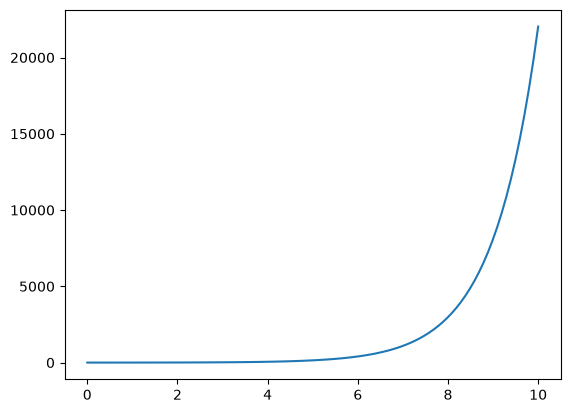

In [10]:
x = np.linspace(0, 10, 100)
plt.plot(x, np.exp(x))


In [15]:
def ets(a, n, x):
    sum = 0
    for k in range(n + 1):
        top = np.exp(a)
        bot = sp.special.factorial(k)
        mul = (x - a) ** k
        sum += (top/bot) * mul
    return sum 

ets(0, 1000, 1.0)

np.float64(2.7182818284590455)

In [21]:
def sts(a, n, x):
    sum = 0
    for k in range(n + 1):
        if k % 4 == 0:
            top = np.sin(a)
        elif k % 4 == 1:
            top = np.cos(a)
        elif k % 4 == 2:
            top = -np.sin(a)
        else:
            top = -np.cos(a)
        bot = sp.special.factorial(k)
        mul = (x - a) ** k
        sum += (top/bot) * mul
    return sum

sts(0, 100, np.pi/2)

np.float64(1.0000000000000002)

In [23]:
def lts(a, n, x):
    sum = 0
    for k in range(n + 1):
        if k == 0:
            sum += np.log(1 + a)
        elif k % 2 == 1:
            topa = sp.special.factorial(k - 1)
            topb = (1 + a) ** k
            top = topa/topb
        else:
            topa = -sp.special.factorial(k - 1)
            topb = (1 + a) ** k
            top = topa/topb
        if k != 0:
            bot = sp.special.factorial(k)
            mul = (x-a) ** k
            sum += (top/bot) * mul
    return sum

lts(0,  10, 0.5)

np.float64(0.4054346478174603)

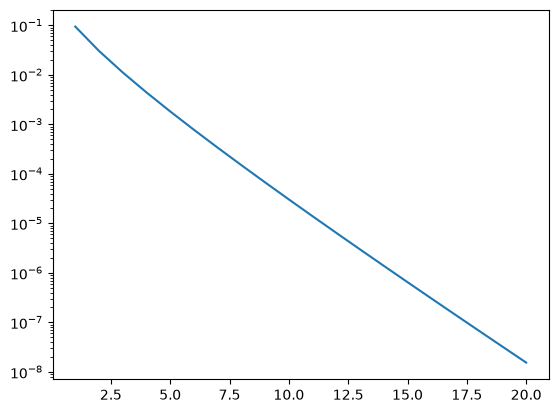

In [33]:
error = []
for i in range(20):
    error.append(abs(lts(0, i+1, 0.5) - np.log(1.5)))
degs = range(1, 21)

plt.semilogy(degs, error)

In [36]:
def df(x):
    return 2 * x

def f(x):
    return x ** 2 - 2

def newton(f, df, x0, tol, max_iter):
    x = [x0]
    for i in range(max_iter):
        xn = x[i] - f(x[i])/df(x[i])
        print(xn)
        if abs(xn - x[-1]) < tol:
            return xn
        x.append(xn)
    return x[-1]

newton(f, df, 2, 1e-8, 100)
    

1.5
1.4166666666666667
1.4142156862745099
1.4142135623746899
1.4142135623730951


1.4142135623730951